# Plot Ground State PEC With Vibrational Energies and Disociation Energies

0.14195628827528414
2.627474754454906
[0.0, 0.27137465108233627, 0.5260320682070295, 0.7639722513740803, 0.985195200583488, 1.1897009158352532, 1.3774893971293758, 1.5485606444658548, 1.7029146578446919, 1.8405514372658858, 1.9614709827294368, 2.0656732942353453, 2.1531583717836105, 2.2239262153742336, 2.2779768250072134, 2.3153102006825503, 2.335926342400245, 2.3398252501602963, 2.3270069239627054, 2.297471363807471, 2.2512185696945948]
0.3762561847603112


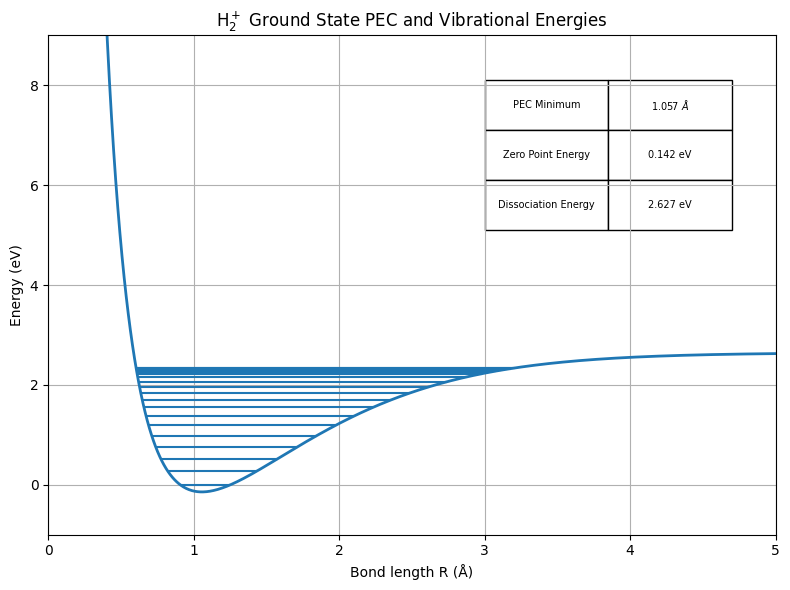

In [49]:
import psi4
import csv
import numpy as np
import matplotlib.pyplot as plt
from psi4.driver.diatomic import anharmonicity
import os

molecule = "h2plus"         #choose molecule
method = "fci"            #choose method

pec = f"{molecule}_{method}_pec-Copy2.csv"        #pec file
vib = f"{molecule}_{method}_vib.csv"        #vibrational energy file

#function to read file
def read_two_col_csv(path):                                      
    R, E = [], []                               #create empty lists to hold distances and energies
    with open(path, "r", newline="") as f:      #open file
        reader = csv.reader(f)                  #create object to read file
        _ = next(reader)  # header              #skips header row
        for row in reader:
            if not row:
                continue
            R.append(float(row[0]))             #add R to list
            E.append(float(row[1]))             #add each E to list
    return np.array(R), np.array(E)             #return lists as arrays

def read_three_col_csv(path):
    Gv, var, val = [], [], []            #set up empty lists for v, Gv, variables, and values
    with open(path, "r", newline="") as f:      #open file
        reader = csv.reader(f)                  #create object to read file
        _ = next(reader)  # header              #skips header row
        for row in reader:
            if not row:
                continue
            Gv.append(float(row[0]))             #add each Gv to list
            var.append((row[1]))                 #add each variable to list
            val.append(float(row[2]))            #add each value to list       
    return Gv, var, val                          #return lists as arrays or lists

R_values, energies = read_two_col_csv(pec)       #get energies and distances
Gv, var, val = read_three_col_csv(vib)           #get vibrational energies

imin = np.argmin(energies)
energies = energies - np.min(energies)

#change to ev
cm_to_ev = 0.0001239841984
hartree_to_ev = 27.211396

Gv_ev = [i * cm_to_ev for i in Gv]
val_ev = [i * cm_to_ev for i in val]

energies_ev = energies*hartree_to_ev

#get zero point energy
variables = dict(zip(var, val_ev))
zpe = variables['ZPVE(anharmonic)']
re = variables['re']/cm_to_ev


print(zpe)
#get dissociation energy
de = energies_ev[-1] - zpe
print(de)

energies_ev = energies_ev - zpe
Gv_ev = [i - zpe for i in Gv_ev]
print(Gv_ev)


def classical_turning_points(R, V, E_level):
    crossings = []

    for i in range(len(R) - 1):
        V1 = V[i]
        V2 = V[i + 1]

        # Check whether the energy level lies between these two PEC points
        if (V1 - E_level) * (V2 - E_level) <= 0:
            # Avoid duplicate points if exactly equal at both ends
            if V2 != V1:
                R1 = R[i]
                R2 = R[i + 1]

                # Linear interpolation
                R_cross = R1 + (E_level - V1) * (R2 - R1) / (V2 - V1)
                crossings.append(R_cross)

    # Remove near-duplicate crossings
    cleaned = []
    for x in crossings:
        if not cleaned or abs(x - cleaned[-1]) > 1e-8:
            cleaned.append(x)

    if len(cleaned) >= 2:
        return cleaned[0], cleaned[-1]
    else:
        return None, None

plt.figure(figsize=(8, 6))

# Original PEC
plt.plot(R_values, energies_ev, linewidth=2)

for E_level in Gv_ev:
    R_left, R_right = classical_turning_points(R_values, energies_ev, E_level)

    if R_left is not None and R_right is not None:
        plt.hlines(y=E_level, xmin=R_left, xmax=R_right)

#for i in range(0, len(Gv_ev)):
#    plt.hlines(y=Gv_ev[i], xmin=0.5, xmax=2)

print(de - Gv_ev[-1])


table_data = [
    ["PEC Minimum",   f"{re:.4} $\AA$"],
    ["Zero Point Energy", f"{zpe:.4} eV"],
    ["Dissociation Energy",  f"{de:.4} eV"],
]

tbl = plt.table(
    cellText=table_data,
    cellLoc="center",
    colLoc="center",
    bbox=[0.6, 0.61, 0.34, 0.3],  # [left, bottom, width, height] in axes fraction
)

plt.xlabel("Bond length R (Å)")
plt.ylabel("Energy (eV)")
plt.title(f"H$_2^+$ Ground State PEC and Vibrational Energies")
plt.ylim(-1, 9)
plt.xlim(0, 5)
plt.grid(True)
plt.tight_layout()

#save image
save_pdf = os.path.join("Ground State Plots", f"{molecule}, {method}, vib.pdf")
save_png = os.path.join("Ground State Plots", f"{molecule}, {method}, vib.png")

plt.savefig(save_pdf, bbox_inches='tight')          # BEST for poster
plt.savefig(save_png, dpi=600, bbox_inches='tight') # backup

plt.show()